# Optimal Transport in linear Independent Component Analysis
### Simulated Experiment: Singe IC extraction with squared Wasserstein Distance

In [53]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import scipy.stats

In [54]:
# Simulating Bernouli sources (s1 and s2) of size n=1000
n = 20
np.random.seed(44)

# Bernoulli symmetric {-1,1}
S1 = np.where(np.random.rand(n) < 0.5, -1.0, 1.0)
S2 = np.where(np.random.rand(n) < 0.5, -1.0, 1.0)

# Stack sources
S = np.vstack([S1, S2])

In [55]:
# generating invertible mixing matrix A
A = np.array([[1, 0.5], [0.4, 1]])

# Mixed signals X
X = A @ S

# Converting to pytorch tensors
S_torch = torch.tensor(S, dtype=torch.float32)
X_torch = torch.tensor(X, dtype=torch.float32)

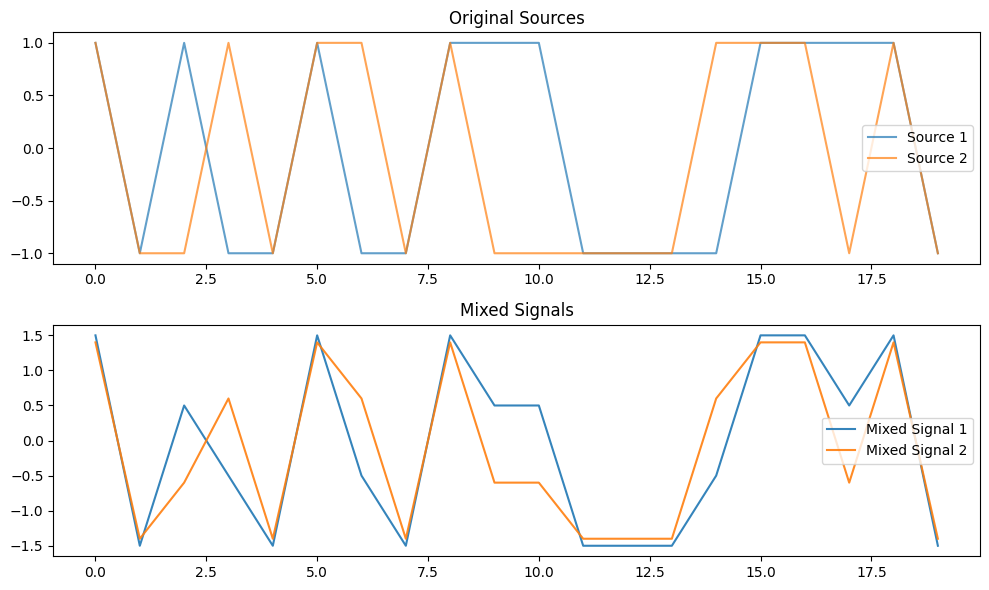

In [56]:
# Plotting sources and mixed signals
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.title("Original Sources")
plt.plot(S1, label='Source 1', alpha=0.7)
plt.plot(S2, label='Source 2', alpha=0.7)
plt.legend()

plt.subplot(2, 1, 2)
plt.title("Mixed Signals")
plt.plot(X[0, :], label='Mixed Signal 1', alpha=0.9)
plt.plot(X[1, :], label='Mixed Signal 2', alpha=0.9)
plt.legend()

plt.tight_layout()
plt.show()

In [57]:
class WassersteinICA:
    def __init__(self, X):
        """
        X: torch tensor of mixed signals (shape: num_signals x num_samples)
        """
        self.X = X
        self.n = X.shape[1]
        self.whitened = False
    
    def whiten(self):
        """
        Whiten the mixture signat, zero mean, unit variance, and uncorrelated.
        """
        # center data
        X_centered = self.X - torch.mean(self.X, dim=1, keepdim=True)
        # compute covariance
        #cov = torch.cov(X_centered)
        cov = torch.matmul(X_centered, X_centered.t()) / (self.n - 1)
        # eigen decomposition
        D, E = torch.linalg.eigh(cov)
        # whitening matrix
        #D_inv_sqrt = torch.diag(1.0 / torch.sqrt(D + 1e-5))
        D_inv_sqrt = torch.diag(1.0 / torch.sqrt(D))
        W = torch.matmul(D_inv_sqrt, E.T)
        self.X_white = torch.matmul(W, X_centered)
        self.whitened = True
    
    def _empirical_quantile(self, y, q):
        """
        Compute empirical quantile of y at quantile level q using sorting.

        y: 1D torch tensor of shape (num_samples,)
        q: 1D torch tensor of quantile levels in [0, 1] of shape (num_quantiles,)
        returns: quantiles at levels q, shape (num_quantiles,)
        """
        sorted_y, _ = torch.sort(y)
        # quantile position indice
        pos = q * (self.n - 1)
        lower = torch.floor(pos).long()
        upper = torch.ceil(pos).long()
        weight = pos - lower.float()
        quantiles = (1 - weight) * sorted_y[lower] + weight * sorted_y[upper]
        return quantiles
    
    def _normal_quantile(self,q):
        """
        Inverse CDF of standard normal distribution at quantile levels.
        q: torch rensor in [0,1]
        """
        q_np = q.cpu().numpy()
        inv_cdf = scipy.stats.norm.ppf(q_np)
        return torch.tensor(inv_cdf, dtype=torch.float32, device=q.device)
    
    def wasserstein2_distance(self, w):
        """
        Compute the squared wasserstein distance from projections w.X and N(0,1)
        
        w: torch tenrsor of shape (num_signals,), unit norm
        returns: scalar, squared wasserstein distance
        """
        assert self.whitened, "Call whiten() before computing Wasserstein distance."
        # project data
        y = torch.mv(self.X_white.t(), w)
        # quantile levels q
        epsilon = 1e-7
        q = torch.linspace(epsilon, 1 - epsilon, steps=self.n, device=self.X.device)
        #q = torch.linspace(0, 1, steps=self.n, device=self.X.device)
        F_y_inv = self._empirical_quantile(y, q)
        F_n_inv = self._normal_quantile(q)
        return torch.mean((F_y_inv - F_n_inv) ** 2)

    def wasserstein1_distance(self, w):
        """
        Compute absolute wasserstein distance from projections w.X and N(0,1)
        
        w: torch tenrsor of shape (num_signals,), unit norm
        returns: scalar, absolute wasserstein distance
        """
        assert self.whitened, "Call whiten() before computing Wasserstein distance."
        # project data
        y = torch.mv(self.X_white.t(), w)
        # quantile levels q
        epsilon = 1e-7
        q = torch.linspace(epsilon, 1 - epsilon, steps=self.n, device=self.X.device)
        F_y_inv = self._empirical_quantile(y, q)
        F_n_inv = self._normal_quantile(q)
        return torch.mean(torch.abs(F_y_inv - F_n_inv))

    def optimize_wasserstein2(self, prev_components=None, grid_points=100, continous=False):
        """
        Find one maximizer of squared wasserstein distance over unit sphere,
        optionally orthogonal to previous components.
        
        Parameters:
        prev_components: None or torch tensor of shape (num_prev_components, num_signals)
        grid_points: int, number of discretization points on the sphere
        continous: bool, if True prints not supported yet message

        Returns:
        w_best: torch tensor of shape (num_signals,), unit norm
        dist_best: float, corresponding maximal squared wasserstein distance
        """
        assert not continous, "Continuous optimization not supported yet."

        angles = torch.linspace(0, 2 * np.pi, steps=grid_points, device=self.X.device)
        candidates = torch.stack([torch.cos(angles), torch.sin(angles)], dim=1)

        if prev_components is not None and prev_components.shape[0] > 0:
            # Orthogonalize candidates w.r.t. previous components
            # using Gram-Schmidt process
            proj = torch.matmul(candidates, prev_components.t())
            candidates = candidates - torch.matmul(proj, prev_components)
            norms = torch.norm(candidates, dim=1, keepdim=True)
            # filter out near zero norms (numerical stability)
            mask = norms.squeeze() > 1e-6
            candidates = candidates[mask]
            if candidates.shape[0] == 0:
                raise ValueError("No valid candidates after orthogonalization.")
            candidates = candidates / norms[mask]
        
        dist_best = -np.inf
        w_best = None
        for w in candidates:
            dist = self.wasserstein2_distance(w)
            dist_val = dist.item()
            if dist_val > dist_best:
                dist_best = dist_val
                w_best = w
        
        return w_best, dist_best

In [58]:
ica = WassersteinICA(X_torch)
ica.whiten()

# whitening check
cov_white = torch.matmul(ica.X_white, ica.X_white.t()) / (ica.n - 1)
# should be identity
print("Whitened covariance:\n", cov_white.numpy())

# Extract first independent component
w1, dist1 = ica.optimize_wasserstein2(grid_points=1000)
print(f"First component Wasserstein-2 distance: {dist1:.4f}, vector: {w1.numpy()}")

# stack first component
prev_components = w1.unsqueeze(0)

# Extract second independent component
#w2, dist2 = ica.optimize_wasserstein2(prev_components=prev_components, grid_points=1000)
#print(f"Second component Wasserstein-2 distance: {dist2:.4f}, vector: {w2.numpy()}")

# project whitened data onto estimated components
proj_S1 = torch.mv(ica.X_white.t(), torch.tensor([1.0, 0.0], dtype=torch.float32))
#proj_S2 = torch.mv(ica.X_white.t(), torch.tensor([0.0, 1.0], dtype=torch.float32))
proj_w1 = torch.mv(ica.X_white.t(), w1)
#proj_w2 = torch.mv(ica.X_white.t(), w2)

Whitened covariance:
 [[ 9.999993e-01 -9.803395e-09]
 [-9.803395e-09  9.999998e-01]]
First component Wasserstein-2 distance: 2.0441, vector: [-0.57935804 -0.81507313]


In [59]:
def compare_components(a, b):
    # Normalize both signals (zero mean, unit variance)
    a_norm = (a - a.mean()) / a.std()
    b_norm = (b - b.mean()) / b.std()
    # Pearson correlation
    corr = torch.abs(torch.corrcoef(torch.stack([a_norm, b_norm]))[0,1]).item()
    # MSE (should be small if signals are close up to sign)
    mse = torch.mean((a_norm - b_norm)**2).item()
    return corr, mse

corr1, mse1 = compare_components(proj_S1, proj_w1)
#corr2, mse2 = compare_components(proj_S2, proj_w2)
print(f"Component 1: |Correlation|={corr1:.4f}, MSE={mse1:.4f}")
#print(f"Component 2: |Correlation|={corr2:.4f}, MSE={mse2:.4f}")

Component 1: |Correlation|=0.5794, MSE=3.0008


In [60]:
# Wasserstein 1 distances

# first component
w1_w1 = ica.wasserstein1_distance(w1)
print(f"Wasserstein-1 distance for first component: {w1_w1.item():.4f}")

# second component
#w2_w1 = ica.wasserstein1_distance(w2)
#print(f"Wasserstein-1 distance for second component: {w2_w1.item():.4f}")

Wasserstein-1 distance for first component: 0.8537


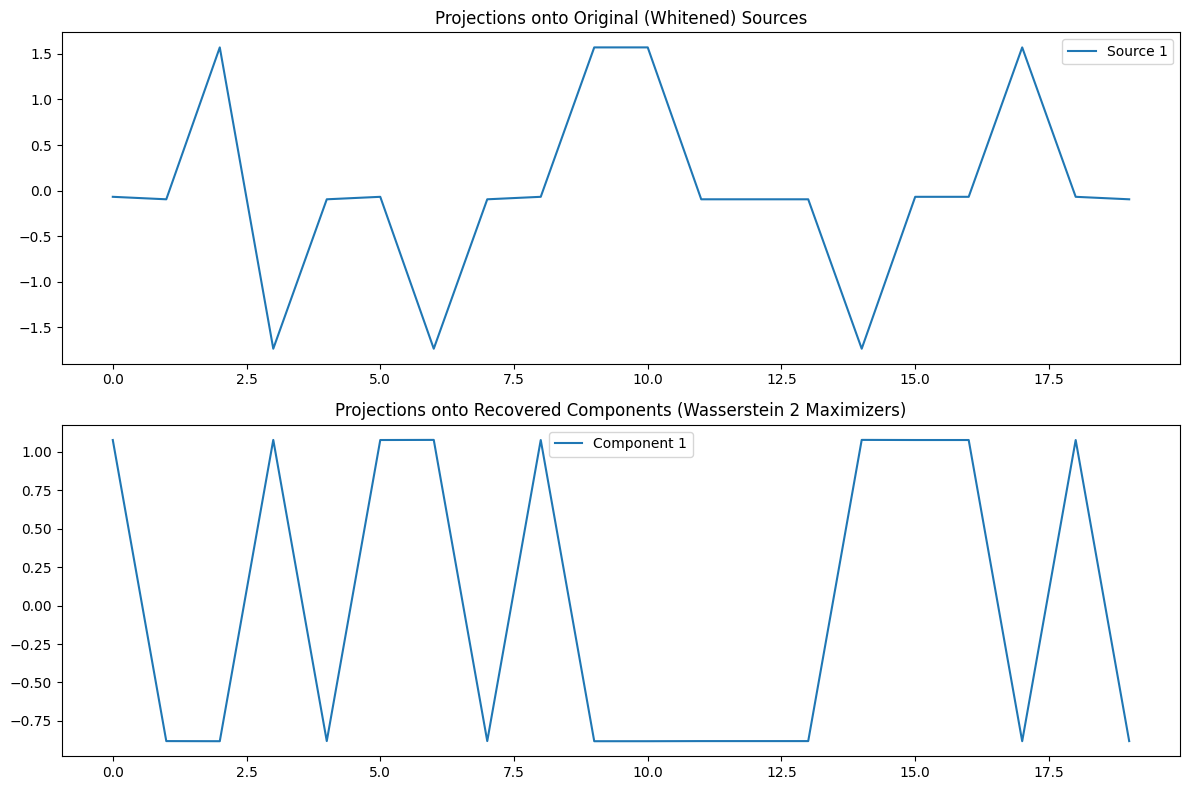

In [61]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.title("Projections onto Original (Whitened) Sources")
plt.plot(proj_S1.numpy(), label="Source 1")
#plt.plot(proj_S2.numpy(), label="Source 2")
plt.legend()

plt.subplot(2, 1, 2)
plt.title("Projections onto Recovered Components (Wasserstein 2 Maximizers)")
plt.plot(proj_w1.numpy(), label="Component 1")
#plt.plot(proj_w2.numpy(), label="Component 2")
plt.legend()

plt.tight_layout()
plt.show()

## Why Wassetstein 1 distance can't be used?

In [75]:
n = 1000000

# Bernoulli sources S1, S2
S1 = np.where(np.random.rand(n) < 0.5, -1, 1)
S2 = np.where(np.random.rand(n) < 0.5, -1, 1)

# torch tensors
S1_t = torch.tensor(S1, dtype=torch.float32)
S2_t = torch.tensor(S2, dtype=torch.float32)

# projection directions for theta = 0, pi/2, pi/4
directions = {
    'theta=0': torch.tensor([1.0, 0.0]),
    'theta=pi/2': torch.tensor([0.0, 1.0]),
    'theta=pi/4': torch.tensor([1/np.sqrt(2), 1/np.sqrt(2)]),
}

# Stack sources
S = torch.stack([S1_t, S2_t], dim=0)  # shape (2, n)

# Compute projections Y_theta
projections = {}
for key, w in directions.items():
    projections[key] = (w.unsqueeze(1) * S).sum(dim=0)  # shape (n,)

In [ ]:
# Initialize WassersteinICA with the sources
ica_explicit = WassersteinICA(S)

#ica_explicit.whiten()

print("Explicit Bernoulli Example Wasserstein Distances:\n")

for key, w in directions.items():
    w = w.to(S.device).to(torch.float32)
    w = w / torch.norm(w)

    # Project original sources with w
    y = torch.mv(S.t(), w)  # shape (n,)

    # temporary 2D tensor as mixture for whitening
    proj_tensor = y.unsqueeze(0)

    # Initialize WassersteinICA with this 1D mixture
    ica_proj = WassersteinICA(proj_tensor)

    ica_proj.whiten()

    # compute distances with weight vector [1] since data is 1D after projection
    w_proj = torch.tensor([1.0], dtype=torch.float32, device=S.device)

    w1_dist = ica_proj.wasserstein1_distance(w_proj)
    w2_dist = ica_proj.wasserstein2_distance(w_proj)

    print(f"{key}: Wasserstein-1 distance = {w1_dist:.4f}, Wasserstein-2 squared distance = {w2_dist:.4f}")


Explicit Bernoulli Example Wasserstein Distances:

theta=0: Wasserstein-1 distance = 0.5354, Wasserstein-2 squared distance = 0.4042
theta=pi/2: Wasserstein-1 distance = 0.5354, Wasserstein-2 squared distance = 0.4042
theta=pi/4: Wasserstein-1 distance = 0.3760, Wasserstein-2 squared distance = 0.2024
